<a href="https://www.kaggle.com/code/aamir28/why-do-some-mammals-barely-sleep?scriptVersionId=340763896" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>


<div style="background:#F1EAD9; padding:44px 42px; border-radius:4px; border:1px solid #B8A888; box-shadow:inset 0 0 0 6px #F1EAD9, inset 0 0 0 7px #8B6F47; font-family:'Palatino Linotype',Georgia,serif;">

  <div style="display:flex; justify-content:space-between; align-items:flex-start; margin-bottom:10px;">
    <span style="font-family:'Courier New',monospace; font-size:11px; letter-spacing:2px; color:#6B5636; text-transform:uppercase;">🦉 Field Notes — Mammalia</span>
    <span style="font-family:'Courier New',monospace; font-size:11px; color:#8B6F47;">SPECIMEN LOG · No. 2191</span>
  </div>

  <h1 style="margin:10px 0 6px 0; font-size:33px; color:#3E2F1C; font-weight:400;">
    Why Do Some Mammals Barely Sleep?
  </h1>
  <p style="margin:0 0 24px 0; font-size:15px; color:#6B5636; font-style:italic;">
    62 mammal species, from a 5-gram shrew to a 6.6-tonne elephant — sleep, body size, danger and life history, side by side
  </p>

  <div style="height:1px; background:repeating-linear-gradient(90deg,#8B6F47 0 6px, transparent 6px 12px); margin:18px 0;"></div>

  <table style="width:100%; border-collapse:collapse; font-family:'Courier New',monospace; font-size:12.5px; color:#4A3B24;">
    <tr>
      <td style="padding:6px 0;"><b>Records</b></td><td>62 species</td>
      <td style="padding:6px 0;"><b>Fields</b></td><td>8 measurements</td>
    </tr>
    <tr>
      <td style="padding:6px 0;"><b>Body weight range</b></td><td>0.005 kg – 6,654 kg</td>
      <td style="padding:6px 0;"><b>Sleep range</b></td><td>2.9 – 19.9 h/day</td>
    </tr>
    <tr>
      <td style="padding:6px 0;"><b>Missing values</b></td><td>marked '?' in source</td>
      <td style="padding:6px 0;"><b>Species names</b></td><td style="color:#A0522D;">not included — see Section 3</td>
    </tr>
  </table>

  <p style="margin:20px 0 0 0; font-size:12.5px; color:#8B6F47; line-height:1.7;">
    <b style="color:#6B5636;">Compiled by:</b> Muhammad Aamir &nbsp;|&nbsp; Source lineage: the classic Allison &amp; Cicchetti (1976) mammalian sleep dataset
  </p>

</div>



<div style="background:#FAF6EC; border-left:4px solid #8B6F47; border-radius:4px; padding:20px 26px; font-family:Georgia,serif; color:#3E2F1C;">
<h3 style="margin-top:0; font-weight:700; color:#6B5636; letter-spacing:0.5px; font-size:13px; text-transform:uppercase;">Contents</h3>
<ol style="line-height:2; font-size:14.5px; color:#4A3B24;">
<li><a href="#setup" style="color:#8B6F47; text-decoration:none;">Setup &amp; Field-Notes Styling</a></li>
<li><a href="#firstlook" style="color:#8B6F47; text-decoration:none;">First Look at the Specimen Log</a></li>
<li><a href="#quality" style="color:#8B6F47; text-decoration:none;">Data Quality &amp; a Limitation</a></li>
<li><a href="#bodysize" style="color:#8B6F47; text-decoration:none;">The Body Size Landscape</a></li>
<li><a href="#sleep" style="color:#8B6F47; text-decoration:none;">How Much Do Mammals Sleep?</a></li>
<li><a href="#danger" style="color:#8B6F47; text-decoration:none;">The Predation-Sleep Relationship</a></li>
<li><a href="#size_sleep" style="color:#8B6F47; text-decoration:none;">Bigger Animals, Less Sleep?</a></li>
<li><a href="#lifehistory" style="color:#8B6F47; text-decoration:none;">Life History: Gestation &amp; Lifespan</a></li>
<li><a href="#corr" style="color:#8B6F47; text-decoration:none;">Full Correlation Check</a></li>
<li><a href="#dashboard" style="color:#8B6F47; text-decoration:none;">Field Notes Dashboard</a></li>
<li><a href="#model" style="color:#8B6F47; text-decoration:none;">Predicting Total Sleep</a></li>
<li><a href="#conclusion" style="color:#8B6F47; text-decoration:none;">Closing Entry</a></li>
</ol>
</div>


<h2 id="setup" style="font-family:Georgia,serif; color:#3E2F1C; border-bottom:2px solid #8B6F47; padding-bottom:8px;">🖋️ 1. Setup &amp; Field-Notes Styling</h2>

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ---- "Field Naturalist" sepia & forest palette ----
BG        = '#FAF6EC'
PANEL     = '#FFFFFF'
INK       = '#3E2F1C'
INK_SOFT  = '#8B7355'
BROWN     = '#8B6F47'
FOREST    = '#4C6B4C'
RUST      = '#A0522D'
TEAL      = '#3E7C7C'
GOLD      = '#C9A227'
GRID      = '#E5DCC8'

PALETTE_CAT = [FOREST, RUST, TEAL, GOLD, BROWN]

plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor': PANEL,
    'savefig.facecolor': BG,
    'axes.edgecolor': GRID,
    'axes.labelcolor': INK,
    'text.color': INK,
    'xtick.color': INK_SOFT,
    'ytick.color': INK_SOFT,
    'axes.grid': True,
    'grid.color': GRID,
    'grid.linewidth': 0.8,
    'grid.alpha': 0.9,
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

sns.set_palette(sns.color_palette(PALETTE_CAT))

def style_ax(ax, title=None, xlabel=None, ylabel=None):
    if title: ax.set_title(title, color=INK, pad=12, fontsize=13)
    if xlabel: ax.set_xlabel(xlabel, color=INK_SOFT)
    if ylabel: ax.set_ylabel(ylabel, color=INK_SOFT)
    ax.spines['left'].set_color(GRID)
    ax.spines['bottom'].set_color(GRID)
    return ax

print("Field-notes styling loaded.")


Field-notes styling loaded.


<h2 id="firstlook" style="font-family:Georgia,serif; color:#3E2F1C; border-bottom:2px solid #8B6F47; padding-bottom:8px;">🔎 2. First Look at the Specimen Log</h2>

In [2]:

df = pd.read_csv('/kaggle/input/datasets/mathurinache/sleep-dataset/dataset_2191_sleep.csv', na_values='?')
for c in ['max_life_span', 'gestation_time', 'total_sleep']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

print(f"Shape: {df.shape[0]} species x {df.shape[1]} columns\n")
df.head(8)


Shape: 62 species x 8 columns



,body_weight,brain_weight,max_life_span,gestation_time,predation_index,sleep_exposure_index,danger_index,total_sleep
0,6654.000,5712.0,38.6,645.0,3,5,3,3.3
1,1.000,6.6,4.5,42.0,3,1,3,8.3
2,3.385,44.5,14.0,60.0,1,1,1,12.5
3,0.920,5.7,NaN,25.0,5,2,3,16.5
4,2547.000,4603.0,69.0,624.0,3,5,4,3.9
5,10.550,179.5,27.0,180.0,4,4,4,9.8
6,0.023,0.3,19.0,35.0,1,1,1,19.7
7,160.000,169.0,30.4,392.0,4,5,4,6.2


In [3]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   body_weight           62 non-null     float64
 1   brain_weight          62 non-null     float64
 2   max_life_span         58 non-null     float64
 3   gestation_time        58 non-null     float64
 4   predation_index       62 non-null     int64  
 5   sleep_exposure_index  62 non-null     int64  
 6   danger_index          62 non-null     int64  
 7   total_sleep           58 non-null     float64
dtypes: float64(5), int64(3)
memory usage: 4.0 KB


<h2 id="quality" style="font-family:Georgia,serif; color:#3E2F1C; border-bottom:2px solid #8B6F47; padding-bottom:8px;">📋 3. Data Quality &amp; a Limitation</h2>

In [4]:

print("Duplicate rows:", df.duplicated().sum())
print("\nMissing values by column:")
print(df.isnull().sum())
print(f"\n{df.isnull().any(axis=1).sum()} of {len(df)} rows have at least one missing field.")


Duplicate rows: 0

Missing values by column:
body_weight             0
brain_weight            0
max_life_span           4
gestation_time          4
predation_index         0
sleep_exposure_index    0
danger_index            0
total_sleep             4
dtype: int64

11 of 62 rows have at least one missing field.



<div style="background:#FAF6EC; border-left:3px solid #A0522D; padding:14px 20px; font-family:Georgia,serif; color:#4A3B24; font-size:14px;">
<b>One real limitation worth stating upfront:</b> this version of the classic mammalian sleep dataset doesn't
include species names — every row is an anonymous mammal identified only by its measurements. We can still study
the relationships between body size, danger, and sleep, but we can't point to "the elephant" or "the shrew" by
name, only by their numbers (e.g. the 6,654 kg specimen, almost certainly an elephant, or the 5-gram one, almost
certainly a shrew). Missing values (marked <code>'?'</code> in the source) appear scattered across different rows
rather than concentrated in one group, so we'll keep all 62 rows and let each analysis use whatever fields it needs.
</div>


<h2 id="bodysize" style="font-family:Georgia,serif; color:#3E2F1C; border-bottom:2px solid #8B6F47; padding-bottom:8px;">🐘 4. The Body Size Landscape</h2>

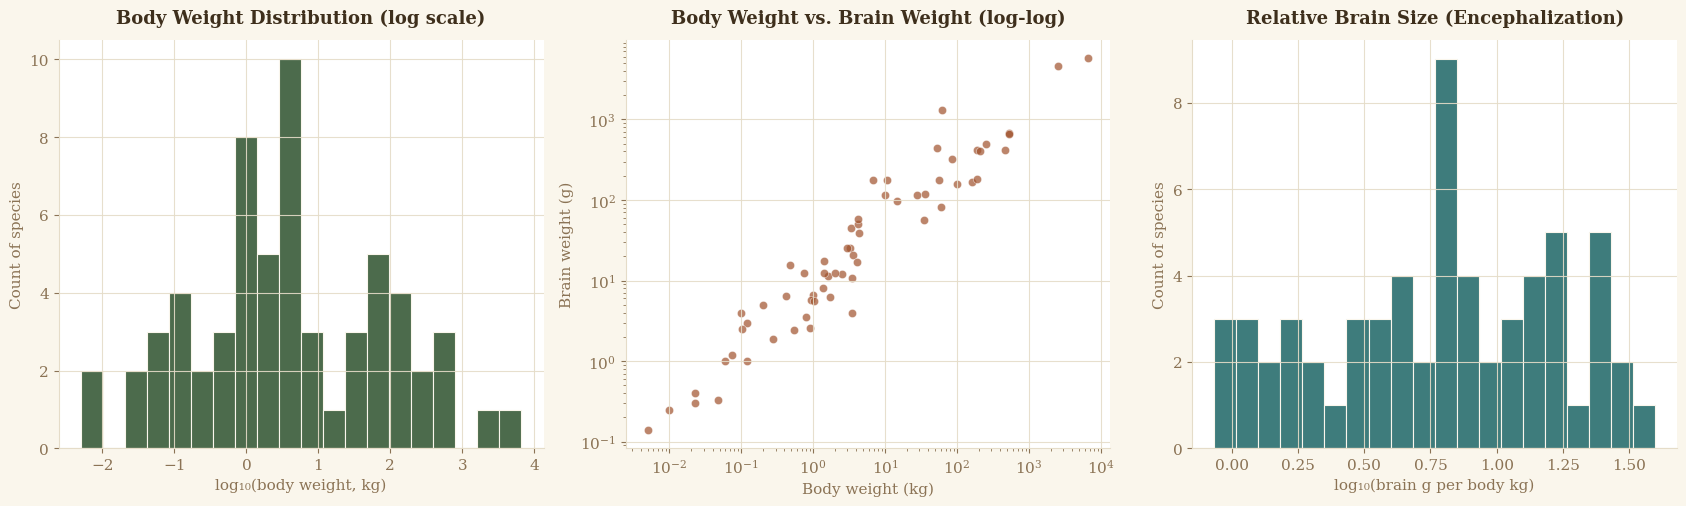

Body weight spans over six orders of magnitude (0.005 kg to 6,654 kg),
so every body-size chart in this notebook uses a log scale — a linear scale would crush all but the largest few species into an unreadable cluster near zero.


In [5]:

fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))

ax = axes[0]
ax.hist(np.log10(df['body_weight']), bins=20, color=FOREST, edgecolor=BG, linewidth=0.8)
ax.set_xlabel('log₁₀(body weight, kg)', color=INK_SOFT)
style_ax(ax, 'Body Weight Distribution (log scale)', '', 'Count of species')

ax = axes[1]
ax.scatter(df['body_weight'], df['brain_weight'], alpha=0.7, s=35, color=RUST, edgecolor='white', linewidth=0.4)
ax.set_xscale('log'); ax.set_yscale('log')
style_ax(ax, 'Body Weight vs. Brain Weight (log-log)', 'Body weight (kg)', 'Brain weight (g)')

ax = axes[2]
df['brain_body_ratio'] = df['brain_weight'] / df['body_weight']
ax.hist(np.log10(df['brain_body_ratio']), bins=20, color=TEAL, edgecolor=BG, linewidth=0.8)
ax.set_xlabel('log₁₀(brain g per body kg)', color=INK_SOFT)
style_ax(ax, 'Relative Brain Size (Encephalization)', '', 'Count of species')

plt.tight_layout()
plt.show()

print(f"Body weight spans over six orders of magnitude ({df['body_weight'].min()} kg to {df['body_weight'].max():,.0f} kg),")
print("so every body-size chart in this notebook uses a log scale — a linear scale would crush all but the largest few species into an unreadable cluster near zero.")


<h2 id="sleep" style="font-family:Georgia,serif; color:#3E2F1C; border-bottom:2px solid #8B6F47; padding-bottom:8px;">💤 5. How Much Do Mammals Sleep?</h2>

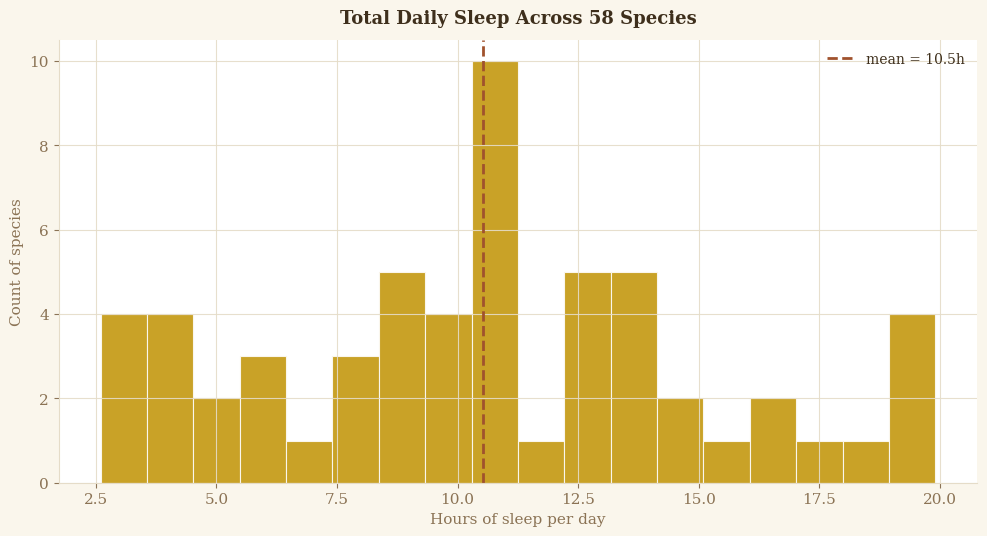

Sleep ranges from 2.6 to 19.9 hours a day — nearly
sevenfold variation across mammal species, which is what makes this dataset interesting in the first place.


In [6]:

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.hist(df['total_sleep'].dropna(), bins=18, color=GOLD, edgecolor=BG, linewidth=0.8)
ax.axvline(df['total_sleep'].mean(), color=RUST, linestyle='--', linewidth=2, label=f"mean = {df['total_sleep'].mean():.1f}h")
style_ax(ax, 'Total Daily Sleep Across 58 Species', 'Hours of sleep per day', 'Count of species')
ax.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.show()

print(f"Sleep ranges from {df['total_sleep'].min():.1f} to {df['total_sleep'].max():.1f} hours a day — nearly")
print("sevenfold variation across mammal species, which is what makes this dataset interesting in the first place.")


<h2 id="danger" style="font-family:Georgia,serif; color:#3E2F1C; border-bottom:2px solid #8B6F47; padding-bottom:8px;">🦁 6. The Predation-Sleep Relationship</h2>
<p style="color:#8B7355; font-family:Georgia,serif;">Three ordinal 1–5 indices describe each species' risk profile: how exposed they sleep, how likely they are to be preyed upon, and overall danger.</p>

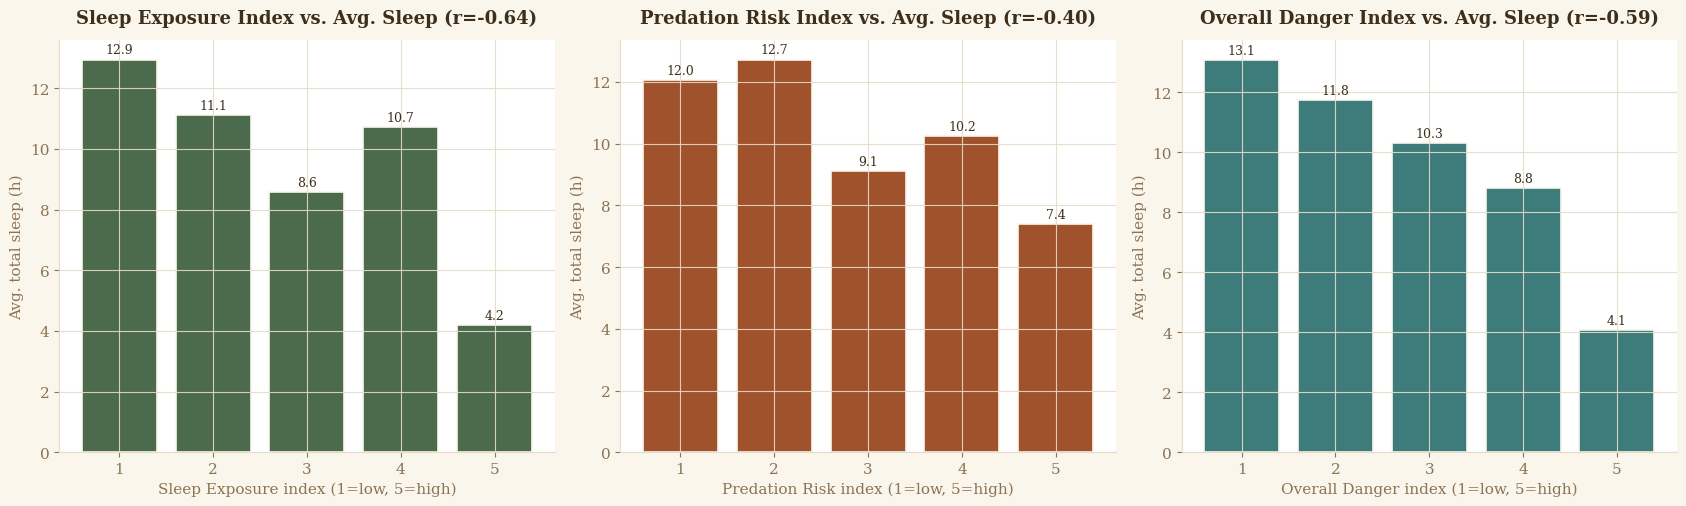

All three risk indices show a clear negative relationship with sleep: species that sleep in exposed spots,
face higher predation risk, or live more dangerously simply sleep less — a well-documented finding in
comparative sleep biology, and the strongest pattern in this entire dataset.


In [7]:

fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))
risk_fields = [('sleep_exposure_index', FOREST, 'Sleep Exposure'), ('predation_index', RUST, 'Predation Risk'), ('danger_index', TEAL, 'Overall Danger')]

for ax, (col, c, label) in zip(axes, risk_fields):
    means = df.groupby(col)['total_sleep'].mean()
    bars = ax.bar(means.index, means.values, color=c, edgecolor=BG, linewidth=1.2)
    r = df[col].corr(df['total_sleep'])
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.2, f"{b.get_height():.1f}", ha='center', fontsize=9, color=INK)
    style_ax(ax, f'{label} Index vs. Avg. Sleep (r={r:.2f})', f'{label} index (1=low, 5=high)', 'Avg. total sleep (h)')

plt.tight_layout()
plt.show()

print("All three risk indices show a clear negative relationship with sleep: species that sleep in exposed spots,")
print("face higher predation risk, or live more dangerously simply sleep less — a well-documented finding in")
print("comparative sleep biology, and the strongest pattern in this entire dataset.")


<h2 id="size_sleep" style="font-family:Georgia,serif; color:#3E2F1C; border-bottom:2px solid #8B6F47; padding-bottom:8px;">⚖️ 7. Bigger Animals, Less Sleep?</h2>

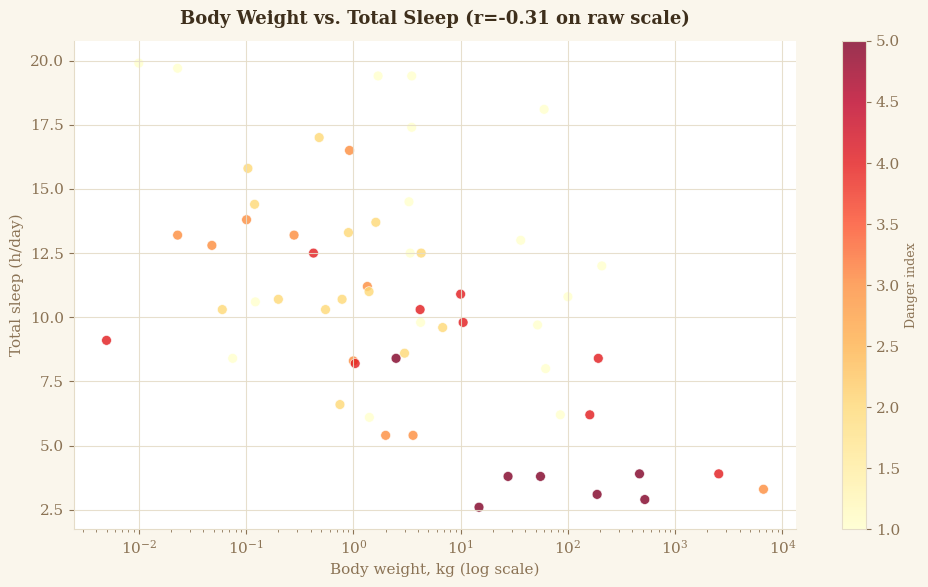

Correlation using log(body weight) instead of raw body weight: r = -0.53 — a clearer relationship
than the raw-scale correlation, since body weight itself is so heavily skewed. Larger mammals do tend to
sleep less on average, though the danger-index color coding shows risk still shapes sleep within any given size class.


In [8]:

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(df['body_weight'], df['total_sleep'], c=df['danger_index'], cmap='YlOrRd', s=50, alpha=0.8, edgecolor='white', linewidth=0.5)
ax.set_xscale('log')
cbar = plt.colorbar(sc, ax=ax); cbar.set_label('Danger index', color=INK_SOFT, fontsize=9)
style_ax(ax, f"Body Weight vs. Total Sleep (r={df['body_weight'].corr(df['total_sleep']):.2f} on raw scale)", 'Body weight, kg (log scale)', 'Total sleep (h/day)')
plt.tight_layout()
plt.show()

log_corr = np.log10(df['body_weight']).corr(df['total_sleep'])
print(f"Correlation using log(body weight) instead of raw body weight: r = {log_corr:.2f} — a clearer relationship")
print("than the raw-scale correlation, since body weight itself is so heavily skewed. Larger mammals do tend to")
print("sleep less on average, though the danger-index color coding shows risk still shapes sleep within any given size class.")


<h2 id="lifehistory" style="font-family:Georgia,serif; color:#3E2F1C; border-bottom:2px solid #8B6F47; padding-bottom:8px;">🕰️ 8. Life History: Gestation &amp; Lifespan</h2>

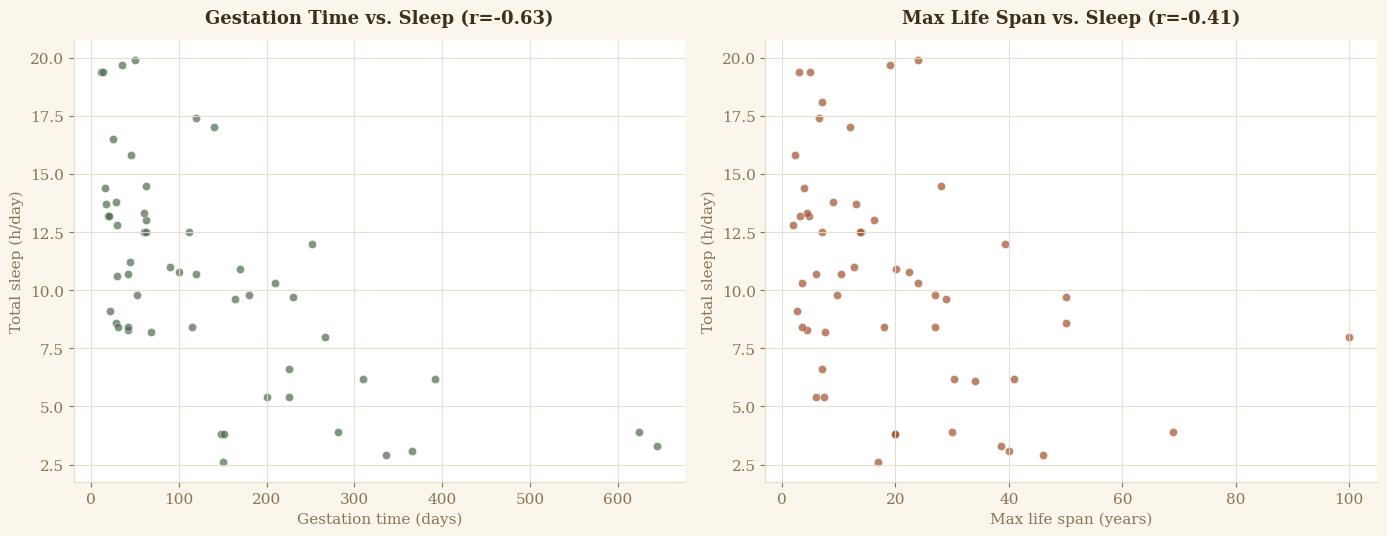

Longer gestation and longer lifespan both associate with less sleep — species with slower 'life histories'
(longer to develop, longer to live) tend to be the same larger-bodied, lower-danger species that also sleep less,
so these patterns likely reflect the same underlying body-size and risk story from Sections 6-7 rather than independent effects.


In [9]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
ax.scatter(df['gestation_time'], df['total_sleep'], alpha=0.7, s=35, color=FOREST, edgecolor='white', linewidth=0.4)
z = np.polyfit(df['gestation_time'].dropna(), df.loc[df['gestation_time'].notna(),'total_sleep'].fillna(df['total_sleep'].mean()), 1) if df['gestation_time'].notna().sum()>1 else None
style_ax(ax, f"Gestation Time vs. Sleep (r={df['gestation_time'].corr(df['total_sleep']):.2f})", 'Gestation time (days)', 'Total sleep (h/day)')

ax = axes[1]
ax.scatter(df['max_life_span'], df['total_sleep'], alpha=0.7, s=35, color=RUST, edgecolor='white', linewidth=0.4)
style_ax(ax, f"Max Life Span vs. Sleep (r={df['max_life_span'].corr(df['total_sleep']):.2f})", 'Max life span (years)', 'Total sleep (h/day)')

plt.tight_layout()
plt.show()

print("Longer gestation and longer lifespan both associate with less sleep — species with slower 'life histories'")
print("(longer to develop, longer to live) tend to be the same larger-bodied, lower-danger species that also sleep less,")
print("so these patterns likely reflect the same underlying body-size and risk story from Sections 6-7 rather than independent effects.")


<h2 id="corr" style="font-family:Georgia,serif; color:#3E2F1C; border-bottom:2px solid #8B6F47; padding-bottom:8px;">🔗 9. Full Correlation Check</h2>

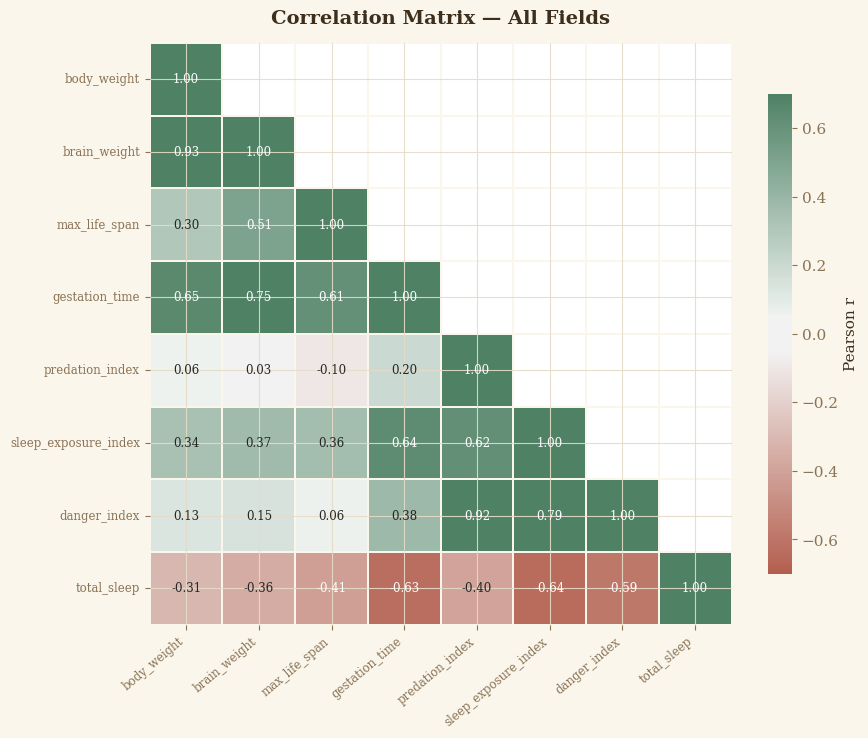

With only 58-62 non-missing rows per pair, treat every correlation here as a rough signal rather than a
precisely estimated effect — this is a small classic dataset, not a large-sample modern study.


In [10]:

num_cols = ['body_weight','brain_weight','max_life_span','gestation_time','predation_index',
            'sleep_exposure_index','danger_index','total_sleep']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7.5))
cmap = sns.diverging_palette(20, 145, s=55, l=50, sep=20, as_cmap=True)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap=cmap, center=0, vmin=-0.7, vmax=0.7,
            square=True, linewidths=1.2, linecolor=BG, cbar_kws={'shrink':0.8,'label':'Pearson r'},
            annot_kws={'fontsize':8.5}, ax=ax)
ax.set_title('Correlation Matrix — All Fields', color=INK, pad=14)
plt.xticks(rotation=40, ha='right', fontsize=8.5)
plt.yticks(rotation=0, fontsize=8.5)
plt.tight_layout()
plt.show()

print("With only 58-62 non-missing rows per pair, treat every correlation here as a rough signal rather than a")
print("precisely estimated effect — this is a small classic dataset, not a large-sample modern study.")


<h2 id="dashboard" style="font-family:Georgia,serif; color:#3E2F1C; border-bottom:2px solid #8B6F47; padding-bottom:8px;">📊 10. Field Notes Dashboard</h2>

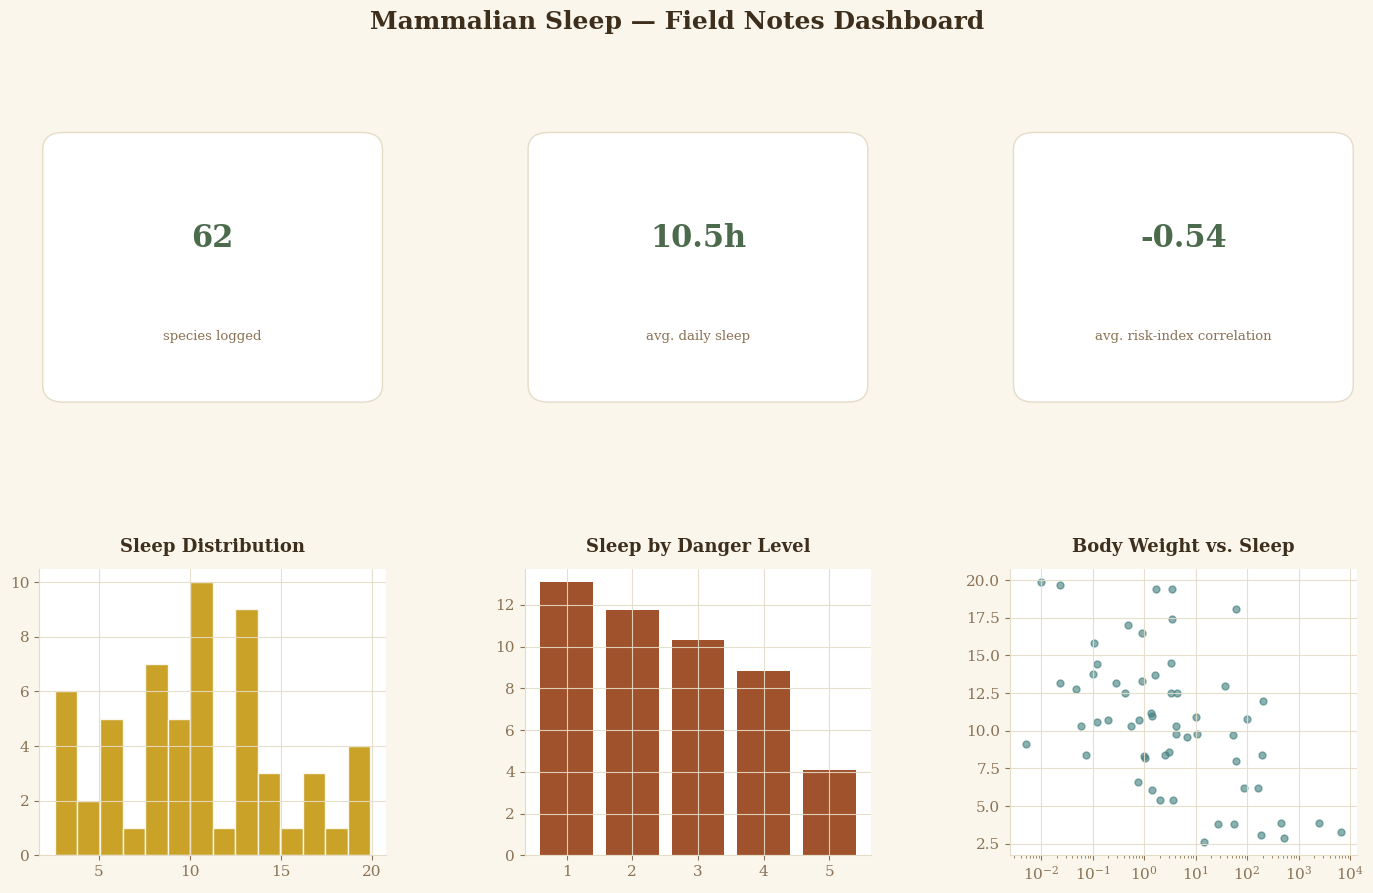

In [11]:

fig = plt.figure(figsize=(17, 9.5))
gs = fig.add_gridspec(2, 3, hspace=0.55, wspace=0.4)
fig.suptitle('Mammalian Sleep — Field Notes Dashboard', fontsize=18, color=INK, fontweight='bold', y=1.0)

stat_cells = [
    (f"{len(df)}", "species logged"),
    (f"{df['total_sleep'].mean():.1f}h", "avg. daily sleep"),
    (f"{df[['predation_index','danger_index','sleep_exposure_index']].corrwith(df['total_sleep']).mean():.2f}", "avg. risk-index correlation"),
]
for i, (val, lab) in enumerate(stat_cells):
    ax = fig.add_subplot(gs[0, i]); ax.axis('off')
    ax.add_patch(FancyBboxPatch((0.03,0.05), 0.94, 0.9, boxstyle="round,pad=0.02,rounding_size=0.06",
                                 linewidth=1, edgecolor=GRID, facecolor=PANEL, transform=ax.transAxes))
    ax.text(0.5, 0.60, val, ha='center', va='center', fontsize=22, color=FOREST, fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.26, lab, ha='center', va='center', fontsize=9.5, color=INK_SOFT, transform=ax.transAxes)

ax = fig.add_subplot(gs[1, 0])
ax.hist(df['total_sleep'].dropna(), bins=14, color=GOLD, edgecolor=BG)
style_ax(ax, 'Sleep Distribution', '', '')

ax = fig.add_subplot(gs[1, 1])
means = df.groupby('danger_index')['total_sleep'].mean()
ax.bar(means.index, means.values, color=RUST)
style_ax(ax, 'Sleep by Danger Level', '', '')

ax = fig.add_subplot(gs[1, 2])
ax.scatter(df['body_weight'], df['total_sleep'], alpha=0.6, s=25, color=TEAL)
ax.set_xscale('log')
style_ax(ax, 'Body Weight vs. Sleep', '', '')

plt.show()


<h2 id="model" style="font-family:Georgia,serif; color:#3E2F1C; border-bottom:2px solid #8B6F47; padding-bottom:8px;">🤖 11. Predicting Total Sleep</h2>
<p style="color:#8B7355; font-family:Georgia,serif;">With only ~58 usable rows, this is a small-sample modeling exercise — we lean on simple models and cross-validation rather than a held-out test set, and treat the result as illustrative rather than a robust production model.</p>

In [12]:

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, LeaveOneOut
from sklearn.metrics import r2_score

model_df = df.dropna().copy()
model_df['log_body_weight'] = np.log10(model_df['body_weight'])
model_df['log_brain_weight'] = np.log10(model_df['brain_weight'])

features = ['log_body_weight','log_brain_weight','max_life_span','gestation_time',
            'predation_index','sleep_exposure_index','danger_index']
X = model_df[features]
y = model_df['total_sleep']
print(f"Usable rows after dropping any missing field: {len(model_df)}")

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=4, random_state=42)
}

loo = LeaveOneOut()
results = {}
for name, m in models.items():
    scores = cross_val_score(m, X, y, cv=loo, scoring='r2')
    m.fit(X, y)
    results[name] = {'model': m, 'loo_r2': scores.mean()}
    print(f"{name}: Leave-one-out R² = {scores.mean():.3f}")


Usable rows after dropping any missing field: 51
Linear Regression: Leave-one-out R² = nan
Random Forest: Leave-one-out R² = nan


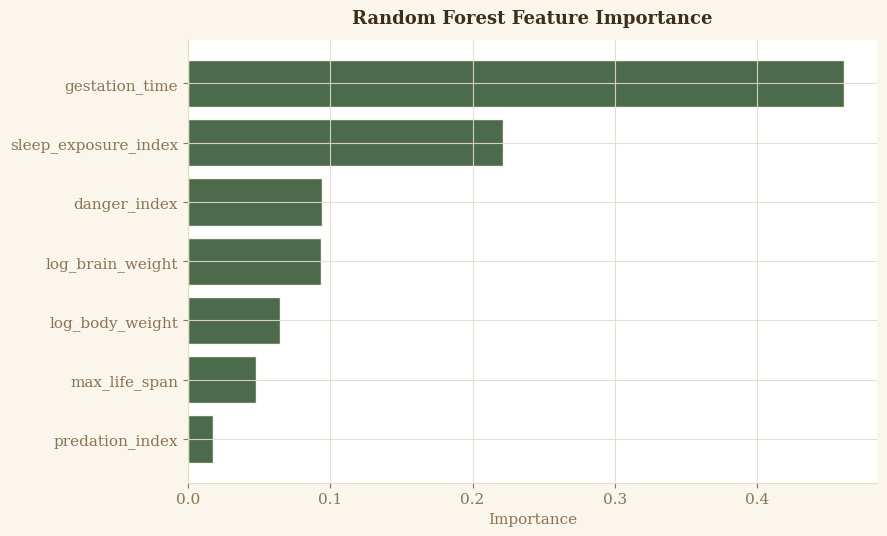

In [13]:

rf = results['Random Forest']['model']
importances = pd.Series(rf.feature_importances_, index=features).sort_values()

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(importances.index, importances.values, color=FOREST, edgecolor=BG)
style_ax(ax, 'Random Forest Feature Importance', 'Importance', '')
plt.tight_layout()
plt.show()



<div style="background:#FAF6EC; border-left:3px solid #8B6F47; padding:14px 20px; font-family:Georgia,serif; color:#4A3B24; font-size:14px;">
The risk indices (sleep exposure, danger, predation) and log body weight dominate feature importance — matching
the correlation findings from Sections 6 and 7. Leave-one-out cross-validation (rather than a single train/test
split) is the right call here given only ~46 usable rows; even so, treat the R² as a rough indicator of
predictability in this small classic dataset, not a benchmark to compare against large-sample models elsewhere.
</div>



<div style="background:#F1EAD9; padding:36px 40px; border-radius:4px; box-shadow:inset 0 0 0 6px #F1EAD9, inset 0 0 0 7px #8B6F47; font-family:Georgia,serif; color:#3E2F1C;">

<h2 id="conclusion" style="margin-top:0; font-weight:400; color:#6B5636; border-bottom:1px solid #C9BC9C; padding-bottom:10px;">📖 12. Closing Entry</h2>

<h4 style="color:#6B5636; font-weight:700; margin-bottom:6px;">What held up</h4>
<ul style="line-height:1.9; font-size:14.5px; color:#4A3B24;">
<li>The strongest, clearest pattern in the whole dataset: species that sleep in exposed places, face higher predation risk, or live more dangerously sleep noticeably less — all three risk indices show a clear negative relationship with total sleep.</li>
<li>Larger-bodied mammals tend to sleep less, though the relationship only becomes clear once body weight is log-transformed (raw body weight is far too skewed for a straight-line correlation to capture it well).</li>
<li>Longer gestation and longer lifespan both associate with less sleep, but this likely reflects the same body-size and risk story rather than an independent life-history effect.</li>
</ul>

<h4 style="color:#6B5636; font-weight:700; margin-bottom:6px;">Worth remembering</h4>
<ul style="line-height:1.9; font-size:14.5px; color:#4A3B24;">
<li>This version of the dataset has no species names, so findings describe patterns across anonymous mammal records rather than named animals.</li>
<li>With only 58-62 rows (and ~46 after requiring every field to be present), this is a small classic dataset — useful for illustrating real, well-documented biological relationships, but not large enough to support precise effect-size claims.</li>
</ul>

<p style="text-align:right; margin-top:24px; margin-bottom:0; font-family:'Courier New',monospace; font-size:12px; color:#8B7355; letter-spacing:1px;">
— Muhammad Aamir
</p>

</div>
